# Is it getting warmer where you live? Fifteen years of weather in twelve cities

Daily temperature and rainfall for **Warsaw, London, Berlin, Madrid, Rome, Athens, Stockholm, Moscow, New York, Tokyo, Sydney and Nairobi, from 2010 to 2024** (5,479 days each). The question sounds simple. Answering it properly is not, and the notebook shows why:

- Weather is dominated by the **seasons**, so the first job is to separate the yearly cycle from everything else.
- A trend over **only 15 years** is noisy. Every number comes with a 95% confidence interval, and the notebook counts how many of the results are really distinguishable from zero.
- Testing many cities and seasons guarantees some false alarms, so the number of "significant" results is compared with the number expected by chance.
- Climate also shows in the **extremes** (hot days, frost days), which need robust statistics for counts.

**Data:** the [Open-Meteo](https://open-meteo.com/) historical weather API, which serves the ERA5 reanalysis (a gridded model of the atmosphere fitted to observations, not readings from one station; free for non-commercial use under CC BY 4.0). The notebook downloads each city once into `CLIMATE_DIR` (about 2 MB in total). The API limits requests per minute, so the first run takes a few minutes.

In [1]:
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats

DATA_DIR = Path(os.environ.get("CLIMATE_DIR", "climate_data"))
DATA_DIR.mkdir(exist_ok=True)
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})

CITIES = {"Warsaw": (52.23, 21.01), "London": (51.51, -0.13), "Berlin": (52.52, 13.40), "Madrid": (40.42, -3.70),
          "Rome": (41.90, 12.50), "Athens": (37.98, 23.73), "Stockholm": (59.33, 18.07), "Moscow": (55.76, 37.62),
          "New York": (40.71, -74.01), "Tokyo": (35.68, 139.69), "Sydney": (-33.87, 151.21), "Nairobi": (-1.29, 36.82)}

## 1. Load the weather

In [2]:
def load_city(name, lat, lon):
    path = DATA_DIR / f"{name.replace(' ', '_')}.json"
    if not path.exists():
        for attempt in range(10):
            try:
                r = requests.get("https://archive-api.open-meteo.com/v1/archive", timeout=60, params={
                    "latitude": lat, "longitude": lon, "start_date": "2010-01-01", "end_date": "2024-12-31",
                    "daily": "temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum", "timezone": "auto"})
            except requests.RequestException:
                time.sleep(30)
                continue
            if r.status_code == 429:                       # the API allows only a few requests a minute
                time.sleep(65)
                continue
            r.raise_for_status()
            path.write_text(json.dumps(r.json()["daily"]), encoding="utf-8")
            time.sleep(8)
            break
    return json.loads(path.read_text(encoding="utf-8"))

frames = []
for name, (lat, lon) in CITIES.items():
    d = load_city(name, lat, lon)
    frames.append(pd.DataFrame({"city": name, "date": pd.to_datetime(d["time"]), "tmean": d["temperature_2m_mean"], "tmax": d["temperature_2m_max"],
                                "tmin": d["temperature_2m_min"], "rain": d["precipitation_sum"]}))
weather = pd.concat(frames, ignore_index=True)
weather["year"] = weather.date.dt.year
weather["month"] = weather.date.dt.month
print(f"{len(weather):,} city-days, {weather.date.min():%Y-%m-%d} to {weather.date.max():%Y-%m-%d}, missing values: {int(weather.isna().sum().sum())}")
annual = weather.groupby("city").agg(mean_temp_c=("tmean", "mean"), hottest_day_c=("tmax", "max"), coldest_night_c=("tmin", "min"),
                                    rain_mm_per_year=("rain", lambda s: s.sum() / 15)).sort_values("mean_temp_c")
annual.round(1)

65,748 city-days, 2010-01-01 to 2024-12-31, missing values: 0


,mean_temp_c,hottest_day_c,coldest_night_c,rain_mm_per_year
city,,,,
Moscow,6.1,37.3,-34.3,620.0
Stockholm,7.5,32.3,-20.8,612.2
Warsaw,9.7,34.9,-27.1,696.4
Berlin,10.5,37.7,-20.5,626.3
London,11.0,37.9,-10.3,703.2
New York,12.4,38.6,-20.5,1228.5
Madrid,15.1,41.5,-11.1,446.0
Tokyo,15.4,39.4,-8.0,1548.5
Rome,16.2,40.1,-10.2,905.5


## 2. Separate the seasons from the rest

A year's temperature curve is almost a sine wave. Fitting a **harmonic regression** (a constant plus a yearly sine and cosine, and their second harmonic for the shape) gives each city's typical year. What is left over, observed minus typical, is the **anomaly**: how unusual each day was. The size of the seasonal swing is itself a good summary of climate: oceanic London and tropical Nairobi barely move, continental Moscow swings a lot.

In [3]:
def harmonics(day_of_year, order=2):
    t = 2 * np.pi * np.asarray(day_of_year) / 365.25
    cols = [np.ones_like(t)]
    for k in range(1, order + 1):
        cols += [np.sin(k * t), np.cos(k * t)]
    return np.column_stack(cols)

fits, rows = {}, []
for city, g in weather.groupby("city"):
    X = harmonics(g.date.dt.dayofyear)
    beta, *_ = np.linalg.lstsq(X, g.tmean.to_numpy(), rcond=None)
    weather.loc[g.index, "seasonal"] = X @ beta
    cycle = harmonics(np.arange(1, 366)) @ beta
    rows.append({"city": city, "coldest_day_of_year": int(np.argmin(cycle)) + 1, "warmest_day_of_year": int(np.argmax(cycle)) + 1,
                 "seasonal_swing_c": cycle.max() - cycle.min(),
                 "share_explained": 1 - np.var(g.tmean - X @ beta) / np.var(g.tmean)})
weather["anomaly"] = weather.tmean - weather.seasonal
seasons = pd.DataFrame(rows).set_index("city").sort_values("seasonal_swing_c")
seasons.round(2)

,coldest_day_of_year,warmest_day_of_year,seasonal_swing_c,share_explained
city,,,,
Nairobi,189,68,3.48,0.54
Sydney,191,33,10.62,0.77
London,20,211,13.47,0.74
Rome,18,213,18.59,0.88
Athens,23,210,19.49,0.88
Berlin,18,203,19.64,0.79
Stockholm,26,203,20.08,0.83
Madrid,5,211,21.87,0.87
Warsaw,18,200,21.89,0.80


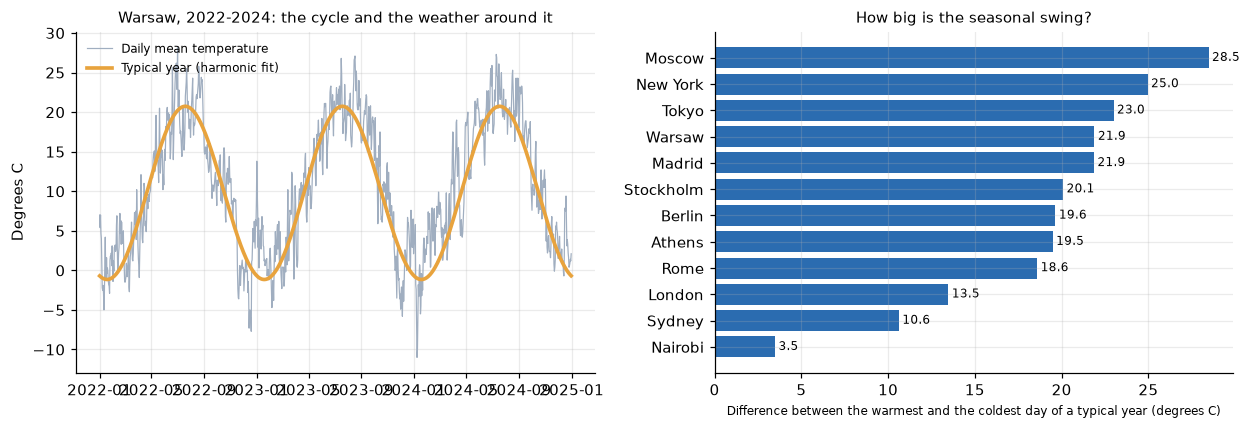

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
w = weather[(weather.city == "Warsaw") & (weather.year.between(2022, 2024))]
axes[0].plot(w.date, w.tmean, color=GREY, lw=0.8, label="Daily mean temperature")
axes[0].plot(w.date, w.seasonal, color=AMBER, lw=2.4, label="Typical year (harmonic fit)")
axes[0].set_ylabel("Degrees C")
axes[0].set_title("Warsaw, 2022-2024: the cycle and the weather around it", fontsize=10)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
axes[1].barh(seasons.index, seasons.seasonal_swing_c, color=BLUE)
for y, v in enumerate(seasons.seasonal_swing_c):
    axes[1].text(v + 0.2, y, f"{v:.1f}", va="center", fontsize=8)
axes[1].set_xlabel("Difference between the warmest and the coldest day of a typical year (degrees C)", fontsize=8)
axes[1].set_title("How big is the seasonal swing?", fontsize=10)
fig.tight_layout()
plt.show()

## 3. Is the average temperature rising?

For each city the yearly mean temperature (2010 to 2024, 15 points) is fitted with a straight line. The slope is the warming in degrees per decade and `linregress` also gives its standard error, from which a **95% confidence interval** follows (t-distribution, 13 degrees of freedom). If the interval does not contain 0 the trend is distinguishable from the year-to-year noise.

In [5]:
yearly = weather.groupby(["city", "year"]).tmean.mean().unstack(0)
t_crit = stats.t.ppf(0.975, df=len(yearly) - 2)
rows = []
for city in yearly.columns:
    res = stats.linregress(yearly.index, yearly[city])
    rows.append({"city": city, "trend_c_per_decade": res.slope * 10, "ci_low": (res.slope - t_crit * res.stderr) * 10,
                 "ci_high": (res.slope + t_crit * res.stderr) * 10, "p_value": res.pvalue,
                 "warmest_year": int(yearly[city].idxmax()), "mean_2024_vs_2010_2019": yearly.loc[2024, city] - yearly.loc[2010:2019, city].mean()})
trend = pd.DataFrame(rows).set_index("city").sort_values("trend_c_per_decade")
trend["distinguishable_from_zero"] = (trend.ci_low > 0) | (trend.ci_high < 0)
print(f"{trend.distinguishable_from_zero.sum()} of {len(trend)} cities have a trend whose 95% interval excludes zero")
trend.round(3)

6 of 12 cities have a trend whose 95% interval excludes zero


,trend_c_per_decade,ci_low,ci_high,p_value,warmest_year,mean_2024_vs_2010_2019,distinguishable_from_zero
city,,,,,,,
Sydney,-0.111,-0.599,0.376,0.629,2016,0.149,False
Nairobi,-0.110,-0.569,0.348,0.612,2024,0.384,False
Athens,0.292,-0.379,0.963,0.364,2024,1.253,False
New York,0.606,-0.132,1.345,0.100,2012,0.928,False
Stockholm,0.717,-0.262,1.695,0.137,2020,0.628,False
Moscow,0.777,-0.022,1.576,0.056,2020,0.990,False
Tokyo,1.125,0.603,1.647,0.000,2024,1.635,True
Rome,1.153,0.847,1.460,0.000,2024,1.243,True
London,1.196,0.508,1.883,0.002,2022,0.975,True


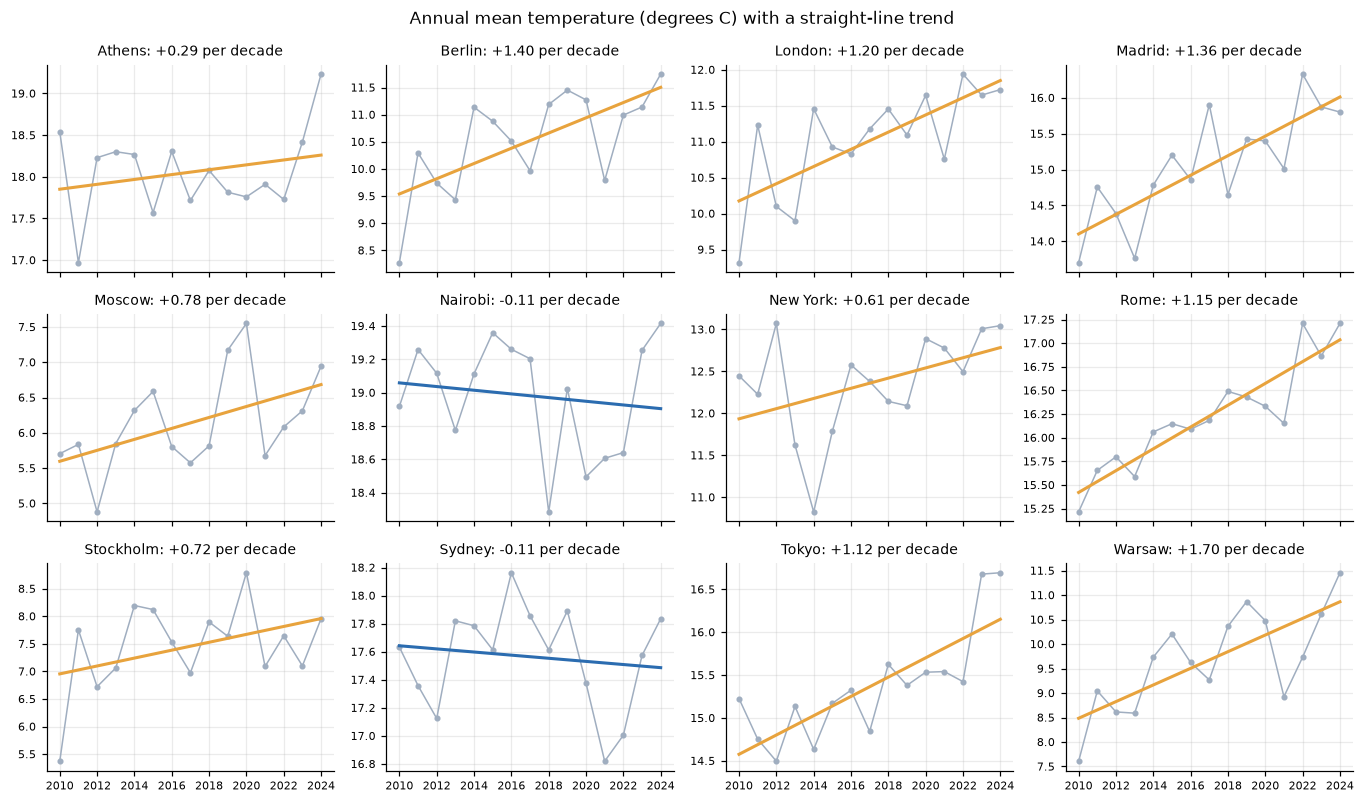

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(12.5, 7.4), sharex=True)
for ax, city in zip(axes.ravel(), yearly.columns):
    row = trend.loc[city]
    res = stats.linregress(yearly.index, yearly[city])
    ax.plot(yearly.index, yearly[city], marker="o", ms=3, color=GREY, lw=1)
    ax.plot(yearly.index, res.intercept + res.slope * yearly.index, color=AMBER if row.trend_c_per_decade > 0 else BLUE, lw=2)
    ax.set_title(f"{city}: {row.trend_c_per_decade:+.2f} per decade", fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle("Annual mean temperature (degrees C) with a straight-line trend", fontsize=11)
fig.tight_layout()
plt.show()

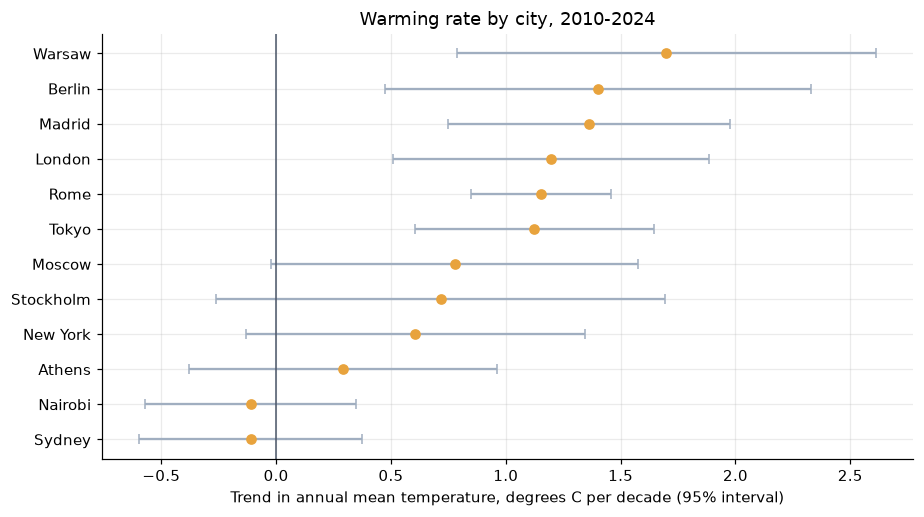

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
y = np.arange(len(trend))
ax.errorbar(trend.trend_c_per_decade, y, xerr=[trend.trend_c_per_decade - trend.ci_low, trend.ci_high - trend.trend_c_per_decade],
            fmt="o", color=AMBER, ecolor=GREY, capsize=3)
ax.axvline(0, color="#4a5568", lw=1)
ax.set_yticks(y, trend.index)
ax.set_xlabel("Trend in annual mean temperature, degrees C per decade (95% interval)")
ax.set_title("Warming rate by city, 2010-2024")
fig.tight_layout()
plt.show()

## 4. When does it warm: winter, spring, summer or autumn?

The same straight-line fit for each meteorological season (December to February is winter, and so on; each December is counted with the following winter). This is 12 cities x 4 seasons = **48 separate tests**, and at a 5% level about 2 to 3 of them will look significant by pure chance. The count below is therefore compared with that expectation.

14 of 48 season-trends are significant at 5%; about 2.4 would be expected by chance alone


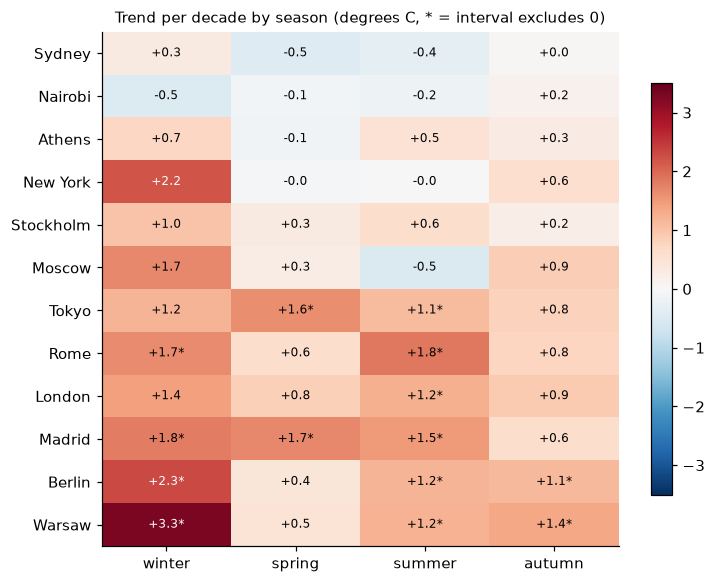

In [8]:
season_of = {12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring",
             6: "summer", 7: "summer", 8: "summer", 9: "autumn", 10: "autumn", 11: "autumn"}
w = weather.assign(season=weather.month.map(season_of), season_year=weather.year + (weather.month == 12).astype(int))
counts = w.groupby(["city", "season", "season_year"]).tmean.agg(["mean", "size"]).reset_index()
counts = counts[counts["size"] >= 88]                      # drop the incomplete first and last winters
rows = []
for (city, season), g in counts.groupby(["city", "season"]):
    res = stats.linregress(g.season_year, g["mean"])
    tc = stats.t.ppf(0.975, df=len(g) - 2)
    rows.append({"city": city, "season": season, "trend": res.slope * 10, "significant": (res.slope - tc * res.stderr > 0) or (res.slope + tc * res.stderr < 0)})
by_season = pd.DataFrame(rows)
grid = by_season.pivot(index="city", columns="season", values="trend")[["winter", "spring", "summer", "autumn"]].loc[trend.index]
sig = by_season.pivot(index="city", columns="season", values="significant")[["winter", "spring", "summer", "autumn"]].loc[trend.index]
print(f"{int(sig.values.sum())} of {sig.size} season-trends are significant at 5%; about {0.05 * sig.size:.1f} would be expected by chance alone")

fig, ax = plt.subplots(figsize=(7, 5.4))
im = ax.imshow(grid.values, cmap="RdBu_r", vmin=-3.5, vmax=3.5, aspect="auto")
ax.set_xticks(range(4), grid.columns)
ax.set_yticks(range(len(grid)), grid.index)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.values[i, j]
        ax.text(j, i, f"{v:+.1f}" + ("*" if sig.values[i, j] else ""), ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 2.0 else "black")
ax.grid(False)
ax.set_title("Trend per decade by season (degrees C, * = interval excludes 0)", fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

## 5. Extremes: hot days and frost

A **hot day** has a maximum of at least 30 degrees C, a **frost day** a minimum below 0, and a **heat wave** is three or more hot days in a row. Counts per year are skewed and short, so the trend uses the **Theil-Sen estimator**, the median of all pairwise slopes, which one odd year cannot drag around, with its own 95% interval.

In [9]:
def longest_run(mask):
    best = run = 0
    for v in mask:
        run = run + 1 if v else 0
        best = max(best, run)
    return best

def heatwave_days(mask, length=3):
    """Days that belong to a run of at least `length` consecutive hot days."""
    total = run = 0
    for v in list(mask) + [False]:
        if v:
            run += 1
        else:
            if run >= length:
                total += run
            run = 0
    return total

rows = []
for (city, year), g in weather.groupby(["city", "year"]):
    hot = (g.tmax >= 30).to_numpy()
    rows.append({"city": city, "year": year, "hot_days": hot.sum(), "heatwave_days": heatwave_days(hot),
                 "frost_days": int((g.tmin < 0).sum()), "rain_mm": g.rain.sum(), "heavy_rain_days": int((g.rain >= 10).sum())})
extremes = pd.DataFrame(rows)

def theil(metric):
    out = []
    for city, g in extremes.groupby("city"):
        slope, intercept, lo, hi = stats.theilslopes(g[metric], g.year, alpha=0.95)
        out.append({"city": city, f"{metric} per year, 2010": g[metric].iloc[:3].mean(), f"{metric} per year, 2022-24": g[metric].iloc[-3:].mean(),
                    "change per decade": slope * 10, "ci_low": lo * 10, "ci_high": hi * 10,
                    "significant": (lo > 0) or (hi < 0)})
    return pd.DataFrame(out).set_index("city")

hot_trend, frost_trend = theil("hot_days"), theil("frost_days")
hot_trend.rename(columns={"hot_days per year, 2010": "first 3 years (avg)", "hot_days per year, 2022-24": "last 3 years (avg)"}).round(1).sort_values("change per decade", ascending=False)

,first 3 years (avg),last 3 years (avg),change per decade,ci_low,ci_high,significant
city,,,,,,
Rome,45.7,83.7,33.3,23.8,52.5,True
Tokyo,39.0,70.3,25.0,-0.0,40.0,False
Sydney,8.3,13.7,7.8,-3.8,18.3,False
Warsaw,5.7,14.0,6.7,-1.4,12.9,False
Berlin,6.0,11.7,6.2,-2.9,12.5,False
New York,39.7,38.3,5.0,-10.0,16.7,False
Madrid,76.7,83.0,5.0,-5.0,16.7,False
London,0.0,3.7,1.8,-0.0,7.8,False
Moscow,12.3,7.0,1.2,-7.8,6.2,False


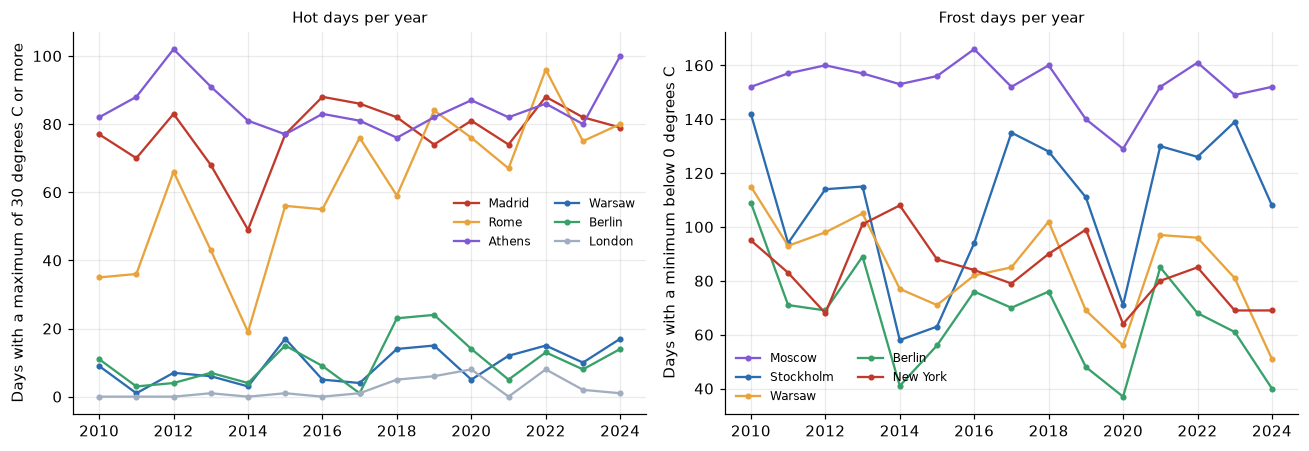

,frost: change per decade,frost: ci_low,frost: ci_high,frost: significant
city,,,,
Warsaw,-22.2,-48.6,-1.1,True
Berlin,-21.8,-45.0,6.2,False
Madrid,-18.5,-39.1,-0.0,False
Tokyo,-14.4,-30.0,1.0,False
New York,-14.3,-35.0,2.0,False
London,-12.9,-37.5,6.7,False


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for city, color in [("Madrid", "#c0392b"), ("Rome", AMBER), ("Athens", "#805ad5"), ("Warsaw", BLUE), ("Berlin", "#38a169"), ("London", GREY)]:
    g = extremes[extremes.city == city]
    axes[0].plot(g.year, g.hot_days, marker="o", ms=3, color=color, label=city)
axes[0].set_ylabel("Days with a maximum of 30 degrees C or more")
axes[0].set_title("Hot days per year", fontsize=10)
axes[0].legend(frameon=False, fontsize=8, ncol=2)
for city, color in [("Moscow", "#805ad5"), ("Stockholm", BLUE), ("Warsaw", AMBER), ("Berlin", "#38a169"), ("New York", "#c0392b")]:
    g = extremes[extremes.city == city]
    axes[1].plot(g.year, g.frost_days, marker="o", ms=3, color=color, label=city)
axes[1].set_ylabel("Days with a minimum below 0 degrees C")
axes[1].set_title("Frost days per year", fontsize=10)
axes[1].legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
plt.show()
pd.concat([frost_trend[["change per decade", "ci_low", "ci_high", "significant"]].add_prefix("frost: ")], axis=1).round(1).sort_values("frost: change per decade").head(6)

## 6. How unusual was 2024? And what about rain?

Where does 2024 rank among the 15 years in each city? And rainfall, which is far more variable from year to year, is tested the same robust way.

In [11]:
rank_2024 = yearly.rank(ascending=False).loc[2024].astype(int).rename("2024 rank (1 = warmest of 15)")
warmest = yearly.idxmax().rename("warmest year")
anomaly_2024 = (yearly.loc[2024] - yearly.loc[2010:2019].mean()).rename("2024 minus 2010-2019 average (C)")
in_context = pd.concat([rank_2024, warmest, anomaly_2024], axis=1).sort_values("2024 rank (1 = warmest of 15)")
print(f"2024 was the warmest of the 15 years in {(rank_2024 == 1).sum()} of {len(rank_2024)} cities")
in_context.round(2)

2024 was the warmest of the 15 years in 6 of 12 cities


,2024 rank (1 = warmest of 15),warmest year,2024 minus 2010-2019 average (C)
city,,,
Athens,1,2024,1.25
Berlin,1,2024,1.46
Rome,1,2024,1.24
Nairobi,1,2024,0.38
Tokyo,1,2024,1.63
Warsaw,1,2024,2.07
New York,2,2012,0.93
London,2,2022,0.98
Moscow,3,2020,0.99


In [12]:
def theil_metric(metric):
    out = []
    for city, g in extremes.groupby("city"):
        slope, _, lo, hi = stats.theilslopes(g[metric], g.year, alpha=0.95)
        out.append({"city": city, "average per year": g[metric].mean(), "change per decade": slope * 10, "ci_low": lo * 10, "ci_high": hi * 10,
                    "significant": (lo > 0) or (hi < 0)})
    return pd.DataFrame(out).set_index("city")

rain_trend = theil_metric("rain_mm")
print(f"annual rainfall: {rain_trend.significant.sum()} of {len(rain_trend)} cities have a trend distinguishable from zero")
rain_trend.round(0).sort_values("change per decade")

annual rainfall: 2 of 12 cities have a trend distinguishable from zero


,average per year,change per decade,ci_low,ci_high,significant
city,,,,,
Berlin,626.0,-91.0,-245.0,89.0,False
Rome,906.0,-46.0,-191.0,198.0,False
Warsaw,696.0,6.0,-149.0,147.0,False
Moscow,620.0,36.0,-94.0,205.0,False
Stockholm,612.0,82.0,-98.0,223.0,False
Madrid,446.0,82.0,-17.0,202.0,False
Nairobi,810.0,99.0,-137.0,620.0,False
Athens,453.0,151.0,-51.0,281.0,False
London,703.0,158.0,1.0,308.0,True


## What the results say

- **Climate shows first in the seasonal swing.** The warmest and the coldest day of a typical year differ by only 3.5 degrees in Nairobi and 10.6 in Sydney, by 13.5 in oceanic London, and by 28.5 in continental Moscow. The yearly sine-wave fit explains 92% of the daily variation in Tokyo and 88% in Rome, but only 54% in Nairobi, where there is hardly a season. Average temperatures range from 6.1 degrees in Moscow to 19.0 in Nairobi; the hottest day was in Athens (43.8) and the coldest night in Moscow (-34.3).
- **Six of the twelve cities are clearly warming.** Fitting a line to the yearly mean temperature, the 95% interval stays above zero for Warsaw (+1.70 degrees per decade, interval 0.79 to 2.61), Berlin (+1.40), Madrid (+1.36), London (+1.20), Rome (+1.15) and Tokyo (+1.13). Moscow (+0.78), Stockholm (+0.72), New York (+0.61) and Athens (+0.29) point the same way but are within the year-to-year noise, and Nairobi and Sydney show no trend (-0.11 for both).
- **These rates cannot be extrapolated.** A fifteen-year window ending in an exceptionally warm year gives rates several times larger than the long-run warming reported by climate agencies, which is a few tenths of a degree per decade. The intervals are also wide (plus or minus 0.3 to 1 degree per decade), which is the honest message of a short record: the direction is clear for half the cities, the exact rate is not.
- **2024 stands out.** It was the warmest of the 15 years in six of the twelve cities (Warsaw, Berlin, Rome, Athens, Tokyo and Nairobi). In Warsaw it was 2.07 degrees above the 2010-2019 average, in Tokyo 1.63 and in Berlin 1.46.
- **Many of the seasonal trends are not chance.** Of the 48 tests (12 cities by 4 seasons), 14 are significant at 5%, where about 2.4 would be by luck alone. Summer is the most consistent (significant in six cities: Tokyo, Rome, London, Madrid, Berlin and Warsaw). Winter has the biggest numbers (+3.3 degrees per decade in Warsaw, +2.3 in Berlin and +2.2 in New York) but winters vary so much from year to year that only four cities (Rome, Madrid, Berlin and Warsaw) are significant, and New York's big number is not.
- **Extremes need robust statistics.** The number of days of 30 degrees or more in Rome rose from about 46 a year in the first three years to about 84 in the last three, a Theil-Sen trend of +33 days per decade (interval 24 to 53), the only clearly significant hot-day trend. Warsaw went from about 6 to 14 hot days a year, but with so few days and so few years the interval still includes zero. Frost days fall most in Warsaw (by 22 days a decade, interval -49 to -1, significant). Berlin, Madrid, Tokyo, New York and London show declines of 13 to 22 days a decade too, but their intervals include zero or only just touch it.
- **Rainfall is mostly noise.** Only two of the twelve cities have a rainfall trend distinguishable from zero (London +158 mm per decade and Sydney +295), against about 0.6 expected by chance, and London's interval only just excludes zero (1 to 308 mm).

**Limits:** fifteen years is short, and the ends of a short series have a large influence on a straight line; the data is ERA5 reanalysis on a grid of about 25 km, not weather station records, so urban heat and very local effects are smoothed out; year-to-year values are treated as independent; the 48 season tests and the other families of tests are not corrected for multiple testing, which is why the count is compared with what chance would produce; twelve cities are not a global sample.

**Techniques covered:** calling a rate-limited API with retries and caching, harmonic regression for seasonality, linear trends with t-based confidence intervals, the Theil-Sen estimator for counts, run-length logic for heat waves, small multiples and heatmaps, and a comparison of significant results with the number expected by chance.
